1. Импорт библиотек и настройки

In [14]:
# Импорт библиотек
import pandas as pd 

# Настройки отображения
pd.set_option('display.max_columns', None)

2. Загрузка данных

In [15]:
# Чтение csv файла 
df = pd.read_csv("sales.csv")

# Чтение excel
# df = pd.read_excel('sales.xlsx')

# Чтение json
# df = pd.read_json('sales.json')

# Чтение parquet
# df = pd.read_parquet('sales.parquet')

# Чтение CSV с указанием кодировки UTF-8
# df = pd.read_csv("sales.csv", encoding="utf-8")

# Чтение CSV с кодировкой cp1251
# df = pd.read_csv("sales.csv", encoding="cp1251")

# Чтение CSV с разделителем ";"
# df = pd.read_csv("sales.csv", sep=";")

3. Первичное знакомство с данными

In [16]:
# Просмотр первых строк 
df.head()

,Invoice ID,Date,Time,Gender,Location,City,Member,Category,Price,Quantity,Total,Payment,Rating
0,460489604,1/25/2018,16:46,Male,Brookfield,NewYork,Yes,Groceries,30,1,30,Cash,2
1,471006167,3/19/2018,16:48,Female,Water tower,Chicago,Yes,Fashion,35,5,175,Card,3
2,411909258,2/25/2018,13:33,Male,Water tower,Chicago,No,Clothing,57,2,114,Cash,5
3,487313402,1/22/2018,13:38,Female,Park lane,Dallas,Yes,Sporting,89,4,356,Gpay,1
4,197763430,2/18/2018,15:31,Female,Park lane,Dallas,No,Books,82,5,410,Cash,4


## Описание атрибутов датасета

- **Invoice ID** - идентификатор покупки
- **Date** - дата покупки
- **Time** - время покупки
- **Gender** - пол клиента
- **Location** - локация
- **City** - город покупки
- **Member** - статус клиента
- **Category** - категория товара
- **Price** - цена товара
- **Quantity** - количество товара
- **Total** - итоговая сумма покупки
- **Payment** - способ оплаты
- **Rating** - оценка сервиса

4. Проверка качества данных

In [17]:
# Проверка данных
print('Размер датасета:')
print(df.shape)

print('\nТипы данных:')
print(df.dtypes)

print('\nКоличество пропущенных значений:')
print(df.isnull().sum())

# Метод для удаления строк с пропущенными значениями 
# df = df.dropna() 


print('\nКоличество дубликатов:')
print(df.duplicated().sum())

# Удаение дубликатов
# df = df.drop_duplicates()

Размер датасета:
(1000, 13)

Типы данных:
Invoice ID     int64
Date          object
Time          object
Gender        object
Location      object
City          object
Member        object
Category      object
Price          int64
Quantity       int64
Total          int64
Payment       object
Rating         int64
dtype: object

Количество пропущенных значений:
Invoice ID    0
Date          0
Time          0
Gender        0
Location      0
City          0
Member        0
Category      0
Price         0
Quantity      0
Total         0
Payment       0
Rating        0
dtype: int64

Количество дубликатов:
0


## Проверка качества данных

На этом этапе выполняется первичная проверка датасета:
- оценка его размерности
- проверка типов данных
- анализ пропущенных значений
- проверка наличия дубликатов

Это позволяет убедиться в корректности данных перед дальнейшей обработкой.

5. Переименование колонок и изменение типов данных 

In [18]:
# Переименование столбцов в snake_case
df = df.rename(columns={
    "Invoice ID": "invoice_id",
    "Date": "date",
    "Time": "time",
    "Gender": "gender",
    "Location": "location",
    "City": "city",
    "Member": "member",
    "Category": "category",
    "Price": "price",
    "Quantity": "quantity",
    "Total": "total",
    "Payment": "payment",
    "Rating": "rating"
    })

# Преобразование даты в datetime формат
df["date"] = pd.to_datetime(df["date"])

# Преобразование времени в формат time
df["time"] = pd.to_datetime(df["time"], format="%H:%M")

Группировка / фильтрация / сортировка 

1 метрика: Анализ выручки по месяцам:

In [19]:
# Создание новой колонки с месяцами 
df["month"] = df["date"].dt.to_period("M")

# Общая выручка по месяцам 
monthly_sales = (
    df.groupby("month")
    .agg({"total": "sum"})
    .reset_index()
    )

print(monthly_sales)

# Cумма выручки по месяцам через выбор столбца
# monthly_sales = df.groupby("month")["total"].sum()

     month  total
0  2018-01  71652
1  2018-02  63850
2  2018-03  72286


По результатам расчета видно, что выручка в феврале ниже, чем в январе и марте.  
Далее разложим эту метрику на составляющие, чтобы понять причину изменения.

In [20]:
print('Подсчёт количества покупок (чеков) по каждому месяцу')
print(df.groupby('month').agg({'invoice_id': 'count'}).reset_index())

print('\nСредний чек по месяцам')
print(df.groupby("month").agg({'total': 'mean'}).reset_index())

print('\nСреднее количество товаров в чеке')
print(df.groupby("month").agg({'quantity': 'mean'}).reset_index())

Подсчёт количества покупок (чеков) по каждому месяцу
     month  invoice_id
0  2018-01         352
1  2018-02         303
2  2018-03         345

Средний чек по месяцам
     month       total
0  2018-01  203.556818
1  2018-02  210.726073
2  2018-03  209.524638

Среднее количество товаров в чеке
     month  quantity
0  2018-01  3.997159
1  2018-02  4.082508
2  2018-03  4.101449


Выручка компании демонстрирует снижение в феврале.  
При этом:
- поведение покупателей (средний чек и корзина) остается стабильным  
- основным фактором изменения является количество транзакций  

*Это может указывать на сезонность или внешние факторы, влияющие на спрос.

2 метрика: Выручка по категориям за февраль

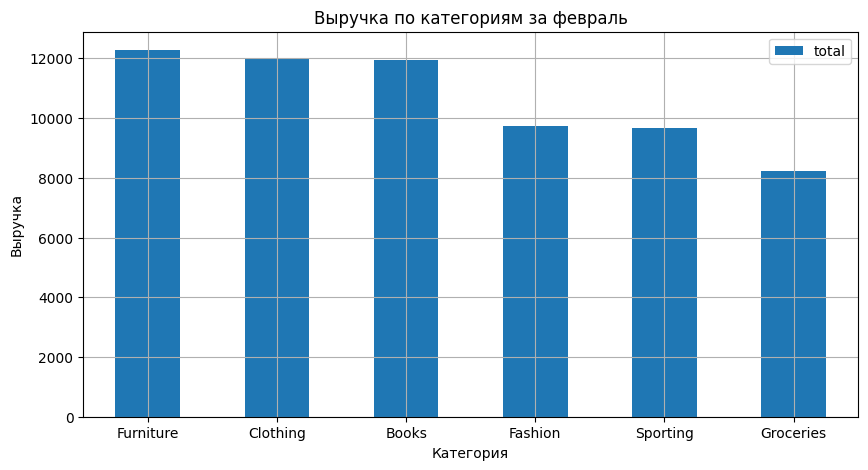

In [21]:
# Выручки по категориям за февраль
top_feb_purchases = df \
    .query("date >= '2018-02-01' and date < '2018-03-01'") \
    .groupby("category") \
    .agg({'total': 'sum'}) \
    .sort_values(by='total', ascending=False) \
    .reset_index()

# Другие способы фильтрации:
    # df[(df["date"] >= "2018-02-01") & (df["date"] < "2018-03-01")]
    # df[df["date"].between("2018-02-01", "2018-02-28")]

# Построение столбчатого графика выручки по категориям за февраль
ax = top_feb_purchases.plot.bar(
    x="category",
    y="total",
    figsize=(10, 5),
    title="Выручка по категориям за февраль"
)

# Подпись оси Y
ax.set_ylabel("Выручка")

# Подпись оси X
ax.set_xlabel("Категория")

# Поворот названий категорий по горизонтали
ax.tick_params(axis='x', rotation=0)

# Добавление сетки
ax.grid(True)

In [22]:
# Сводная таблица выручки по месяцам и категориям
pivot_revenue = df.pivot_table(
    index="month",
    columns="category",
    values="total",
    aggfunc="sum"
)

pivot_revenue

category,Books,Clothing,Fashion,Furniture,Groceries,Sporting
month,,,,,,
2018-01,12339,11861,9849,11679,10446,15478
2018-02,11931,11997,9736,12276,8235,9675
2018-03,11833,12067,13193,10186,12555,12452


В данной таблице:
- `index` - строки таблицы
- `columns` - колонки таблицы
- `values` - значения для агрегации
- `aggfunc` - функция агрегации

Pivot table позволяет быстро анализировать структуру выручки по категориям и месяцам.

### merge/concat

In [23]:
# Создание справочника категорий
categories_df = pd.DataFrame({
    "category": [
        "Books",
        "Clothing",
        "Fashion",
        "Furniture",
        "Groceries",
        "Sporting"
    ],
    "category_type": [
        "Education",
        "Apparel",
        "Apparel",
        "Home",
        "Food",
        "Sport"
    ]
})

# Соединение основного датафрейма со справочником категорий
df = df.merge(
    categories_df,
    on="category",
    how="left"
)

# Виды merge: 
# left - сохраняет все строки из основной таблицы (используется в данном проекте)
# right - сохраняет все строки из справочника
# inner -  оставляет только совпадающие записи
# outer - объединяет все записи из обеих таблиц


# Просмотр первых строк обновленного датафрейма
df.head()

,invoice_id,date,time,gender,location,city,member,category,price,quantity,total,payment,rating,month,category_type
0,460489604,2018-01-25,1900-01-01 16:46:00,Male,Brookfield,NewYork,Yes,Groceries,30,1,30,Cash,2,2018-01,Food
1,471006167,2018-03-19,1900-01-01 16:48:00,Female,Water tower,Chicago,Yes,Fashion,35,5,175,Card,3,2018-03,Apparel
2,411909258,2018-02-25,1900-01-01 13:33:00,Male,Water tower,Chicago,No,Clothing,57,2,114,Cash,5,2018-02,Apparel
3,487313402,2018-01-22,1900-01-01 13:38:00,Female,Park lane,Dallas,Yes,Sporting,89,4,356,Gpay,1,2018-01,Sport
4,197763430,2018-02-18,1900-01-01 15:31:00,Female,Park lane,Dallas,No,Books,82,5,410,Cash,4,2018-02,Education


In [24]:
# Данные за январь
jan_sales = df[df["month"] == "2018-01"]

# Данные за февраль
feb_sales = df[df["month"] == "2018-02"]

# Объединение датасетов
combined_sales = pd.concat([jan_sales, feb_sales])

# Просмотр результата
combined_sales.head()

,invoice_id,date,time,gender,location,city,member,category,price,quantity,total,payment,rating,month,category_type
0,460489604,2018-01-25,1900-01-01 16:46:00,Male,Brookfield,NewYork,Yes,Groceries,30,1,30,Cash,2,2018-01,Food
3,487313402,2018-01-22,1900-01-01 13:38:00,Female,Park lane,Dallas,Yes,Sporting,89,4,356,Gpay,1,2018-01,Sport
8,325637547,2018-01-18,1900-01-01 15:33:00,Male,Park lane,Dallas,Yes,Clothing,91,3,273,Card,3,2018-01,Apparel
12,149894432,2018-01-12,1900-01-01 11:12:00,Male,Park lane,Dallas,No,Clothing,77,5,385,Cash,4,2018-01,Apparel
13,942406749,2018-01-18,1900-01-01 15:20:00,Female,Water tower,Chicago,Yes,Clothing,9,6,54,Gpay,5,2018-01,Apparel


### Отличие merge от concat

- `merge` — соединяет таблицы по ключу (аналог SQL JOIN)
- `concat` — объединяет таблицы по строкам или колонкам (аналог SQL UNION ALL)